# Chapter 1

In [1]:
import torch
from torch import tensor
import numpy as np
import matplotlib.pyplot as plt
from fastai.vision.all import *
from fastbook import *

## Cat vs. dog classifier

- A state-of-the-art image classifier is ~6 lines of fastai: download data → build `DataLoaders` → `vision_learner` → `fine_tune`.
- *Transfer learning*: `resnet34` comes pretrained on ImageNet; `fine_tune(1)` only adapts it to cats/dogs — that's why one epoch is enough.
- The labels come from a filename convention in the Oxford-IIIT Pet dataset: cat breeds start with an **uppercase** letter, dogs lowercase. `is_cat` just checks `x[0].isupper()` — the "label" is hidden in the filename.
- `valid_pct=0.2, seed=42`: 20% of images are held back for validation, and the seed makes the split reproducible.
- `learn.predict(img)` returns 3 things: the predicted label, its index, and a tensor of probabilities — `probs[1]` is the probability for "cat" (index 1 = `True` in the sorted vocab `[False, True]`).

In [2]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

learn = vision_learner(dls, resnet34, metrics=error_rate)
# comment out for testing without fine tuning
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.177165,0.030075,0.012179,01:01


epoch,train_loss,valid_loss,error_rate,time
0,0.042911,0.021101,0.006766,00:50


Is this a cat?: True.
Probability it's a cat: 1.000000


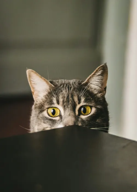

In [3]:
def check_image(path):
    img = PILImage.create(path)
    is_cat, _, probs = learn.predict(img)
    print(f"Is this a cat?: {is_cat}.")
    print(f"Probability it's a cat: {probs[1].item():.6f}")
    return img.to_thumb(192)

check_image('my_images/cat1.webp')

Is this a cat?: False.
Probability it's a cat: 0.008717


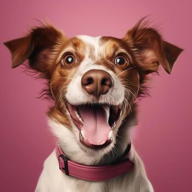

In [4]:
check_image('my_images/dog.jpg')